In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

ext = 'png'
plot_dir = Path(f'validation_amr_ric_{ext}')
plot_dir.mkdir(exist_ok=True)

In [2]:
from clustering_statistics.systematic_templates import get_smooth_template

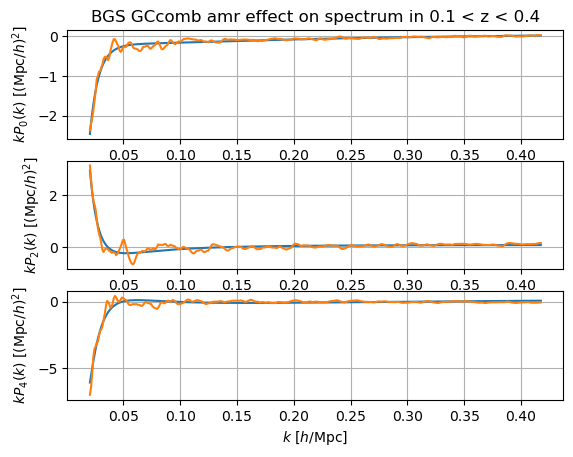

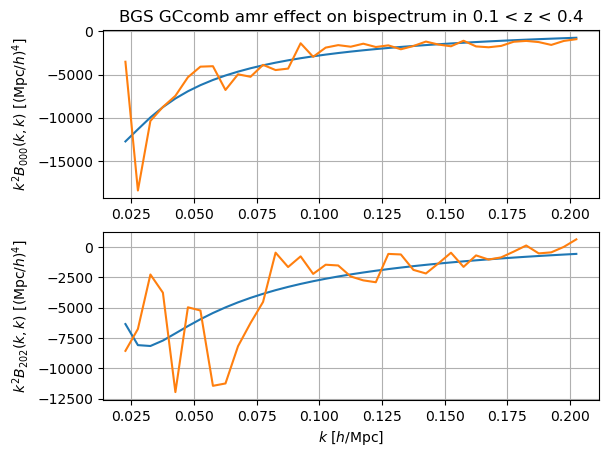

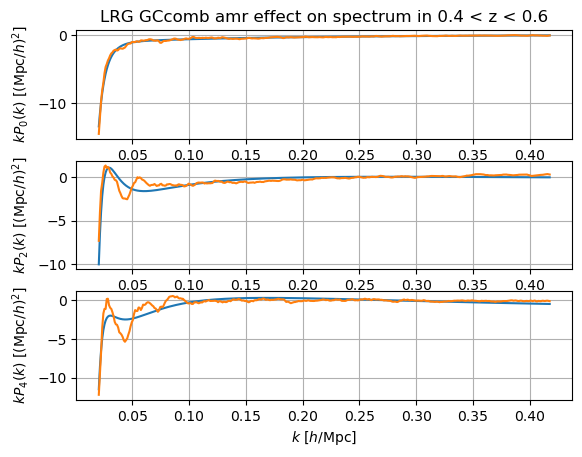

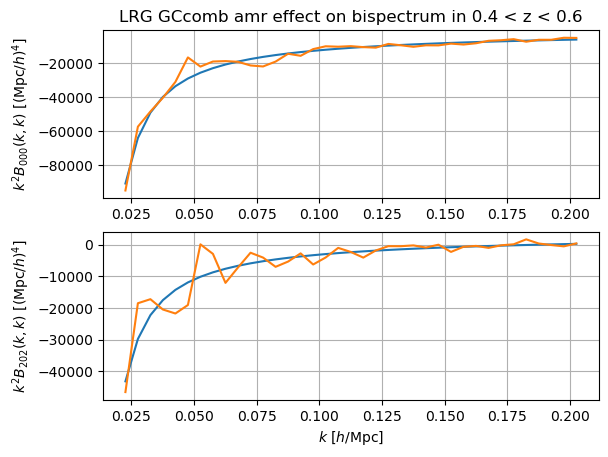

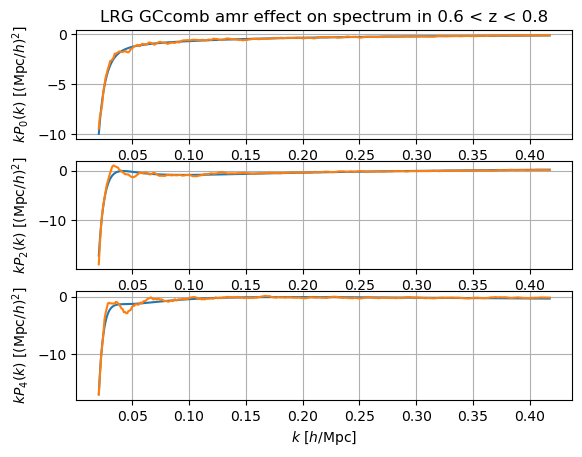

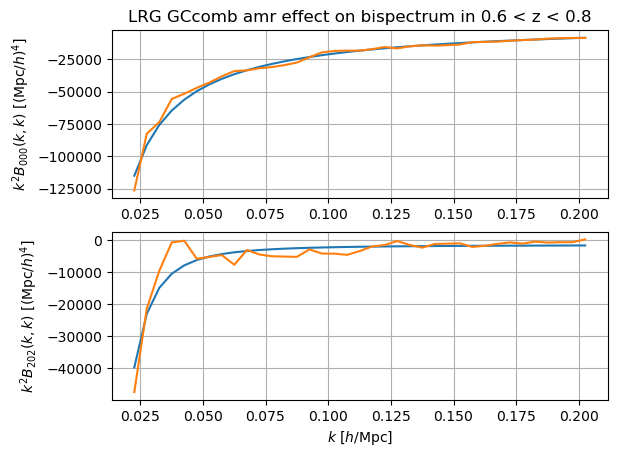

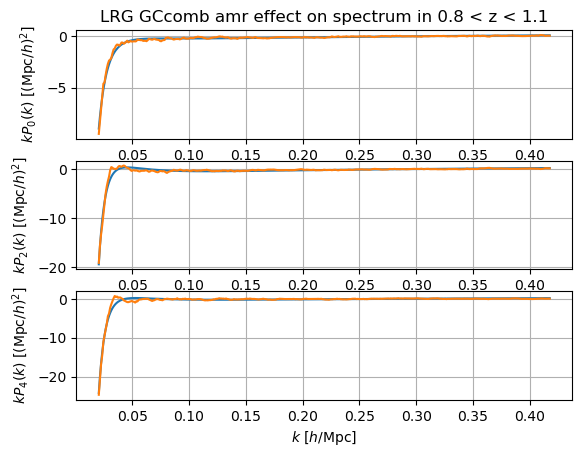

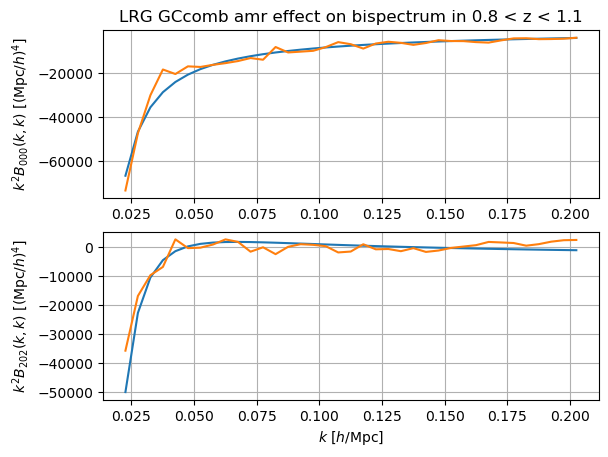

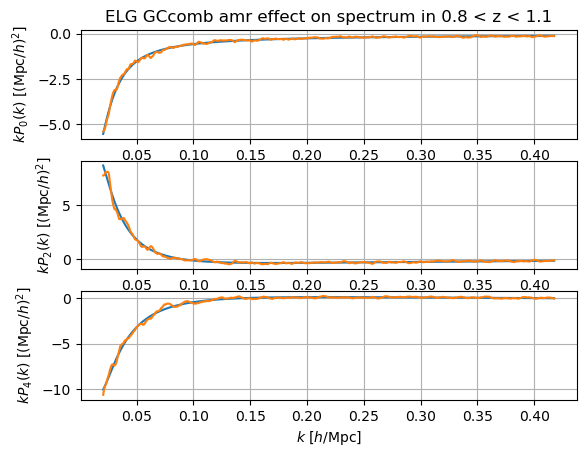

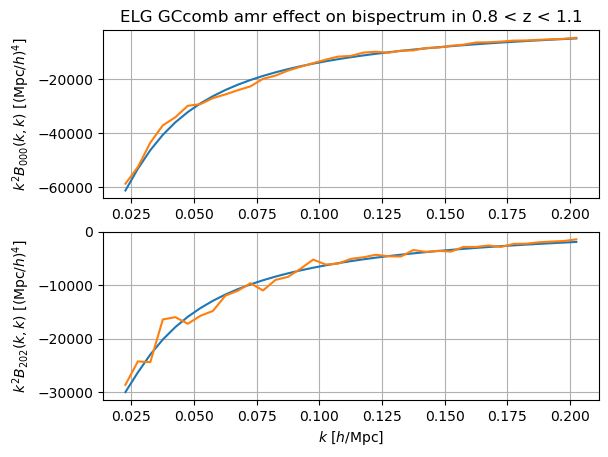

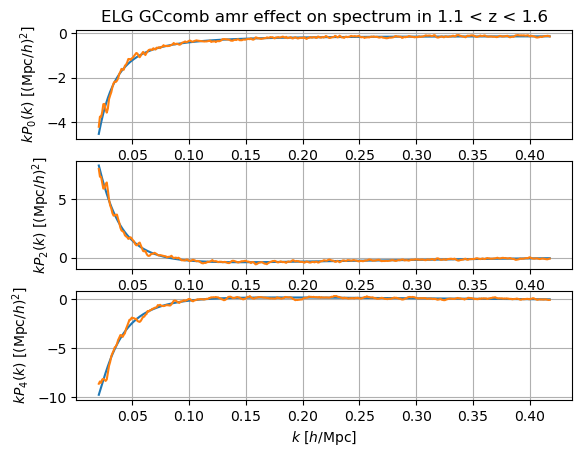

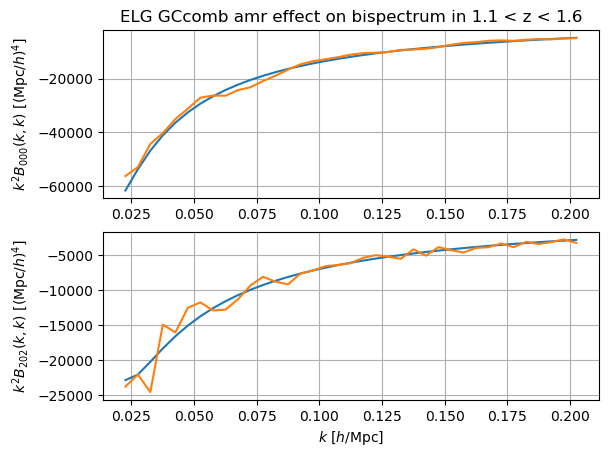

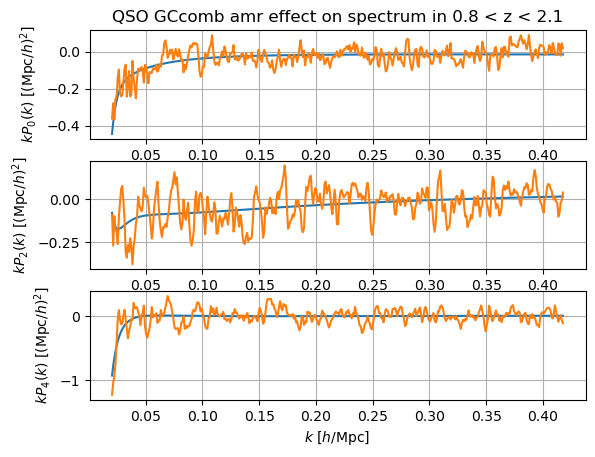

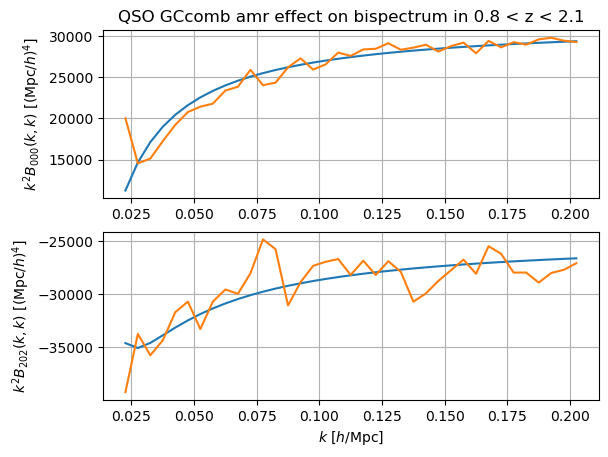

In [3]:
region = 'GCcomb'

for effect in ['amr', 'ric'][:1]:
    for tracer in ['BGS', 'LRG', 'ELG', 'QSO']:
        for zrange in tools.propose_fiducial('zranges', tracer):
            for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
                smooth, effects, noeffects = get_smooth_template(tracer=tracer, zrange=zrange, region=region, effect=effect, kind=kind, return_stats=True)
                mean_effect, mean_noeffect = types.mean(effects), types.mean(noeffects)
                smooth = smooth.select(k=(0.02, 1.))
                mean_effect, mean_noeffect = mean_effect.match(smooth), mean_noeffect.match(smooth)
                fig, lax = plt.subplots(len(smooth.ells))
                lax = lax.ravel()
                if kind == 'mesh2_spectrum':
                    lax[0].set_title(f'{tracer} {region} {effect} effect on spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                    for ill, ell in enumerate(smooth.ells):
                        pole = smooth.get(ell)
                        ax = lax[ill]
                        ax.plot(k:=pole.coords('k'), k * pole.value(), linestyle='-', color='C0')
                        pole_effect, pole_noeffect = mean_effect.get(ell), mean_noeffect.get(ell)
                        ax.plot(k:=pole_effect.coords('k'), k * (pole_effect.value() - pole_noeffect.value()), linestyle='-', color='C1')
                        ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                        ax.grid(True)
                    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                elif kind == 'mesh3_spectrum':
                    lax[0].set_title(f'{tracer} {region} {effect} effect on bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                    for ill, ell in enumerate(smooth.ells):
                        pole = smooth.get(ell)
                        ax = lax[ill]
                        ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), linestyle='-', color='C0')
                        pole_effect, pole_noeffect = mean_effect.get(ell), mean_noeffect.get(ell)
                        ax.plot(k:=pole_effect.coords('k')[..., 0], k**2 * (pole_effect.value() - pole_noeffect.value()), linestyle='-', color='C1')
                        ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                        ax.grid(True)
                    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')

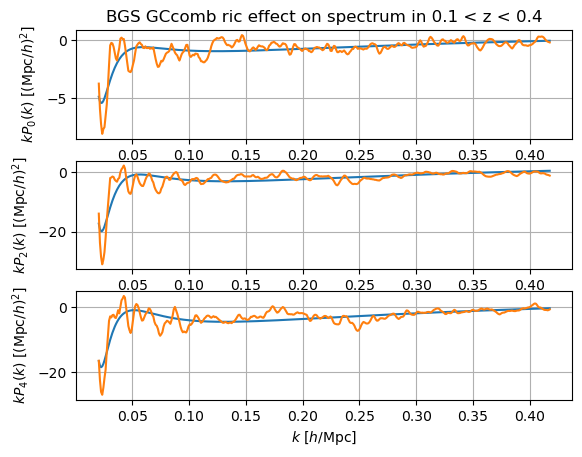

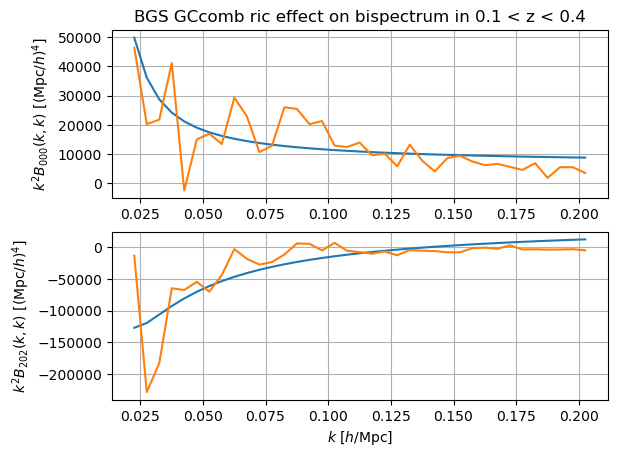

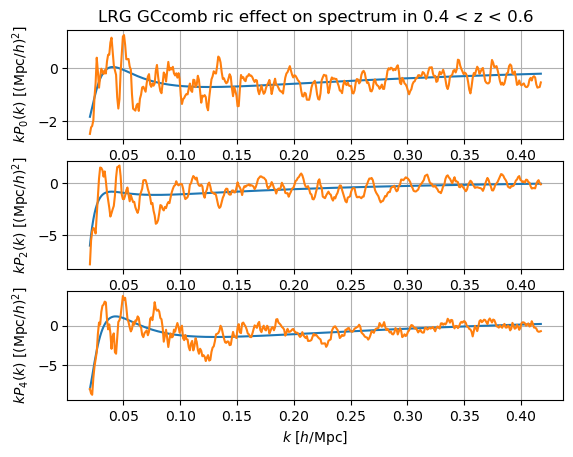

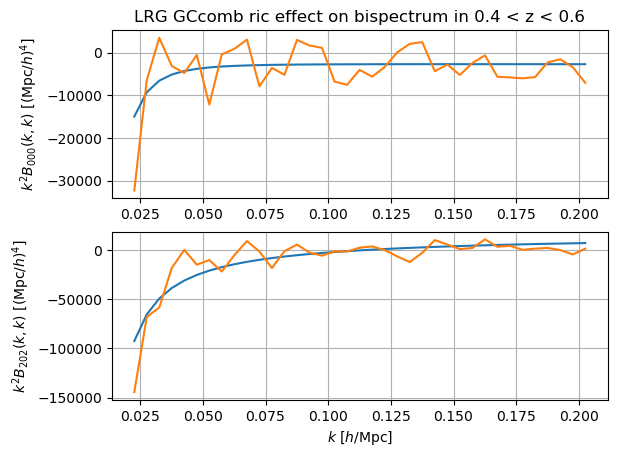

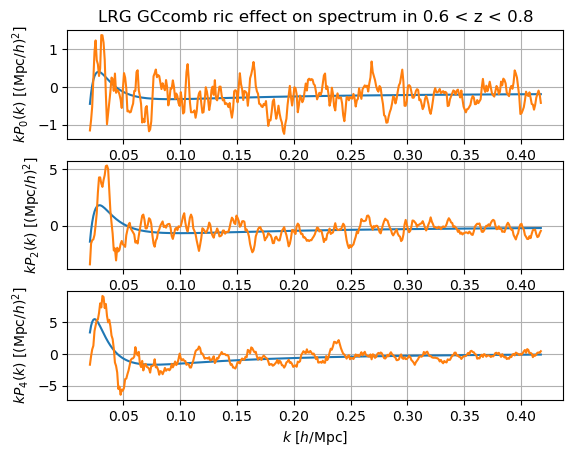

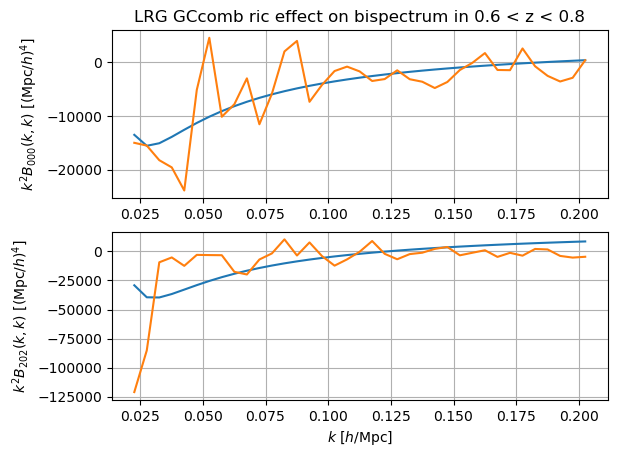

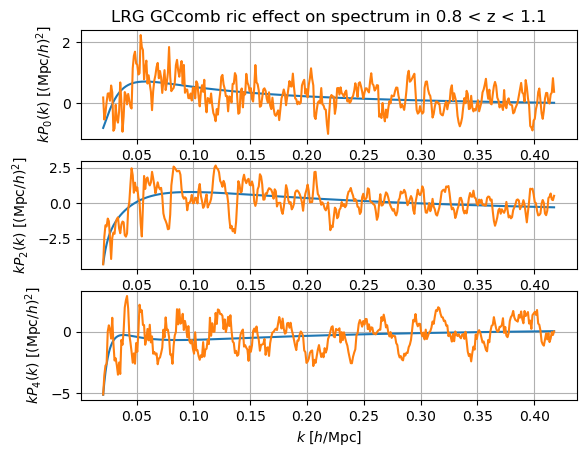

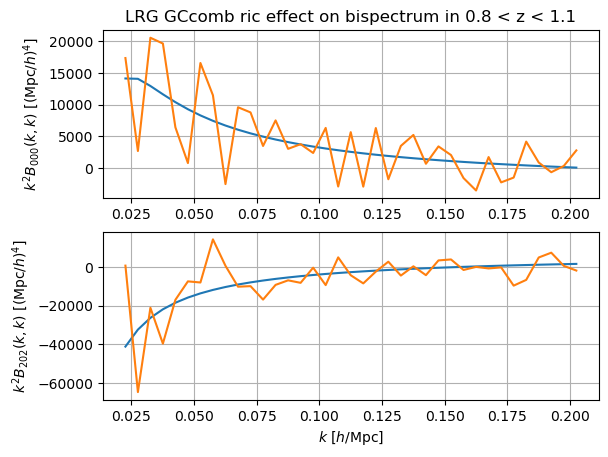

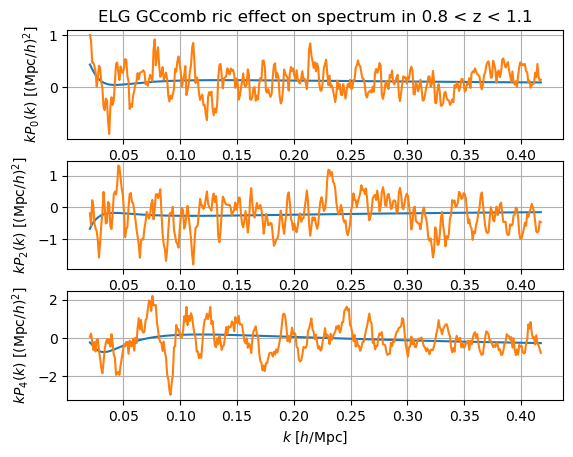

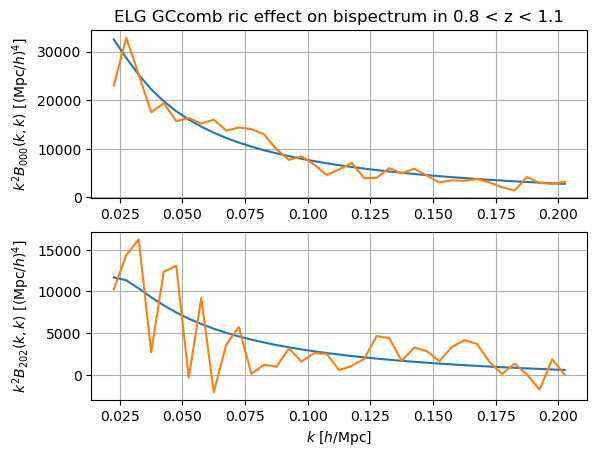

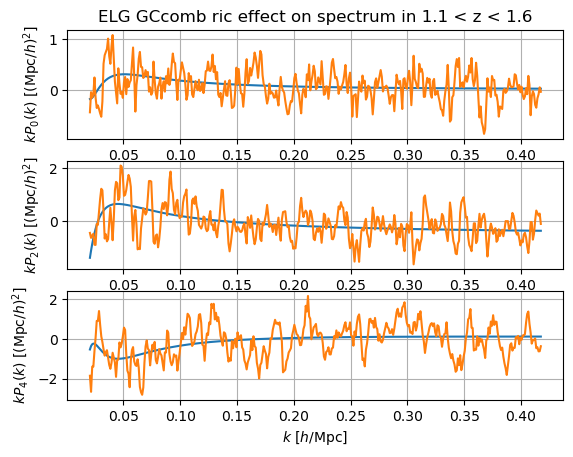

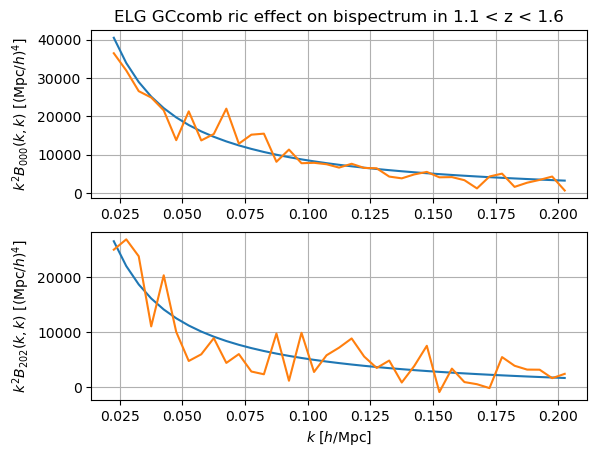

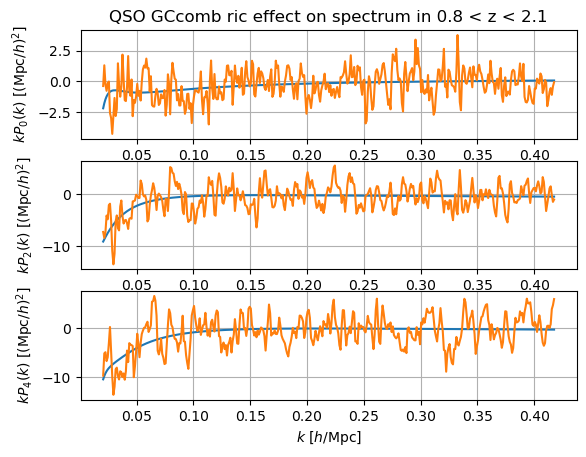

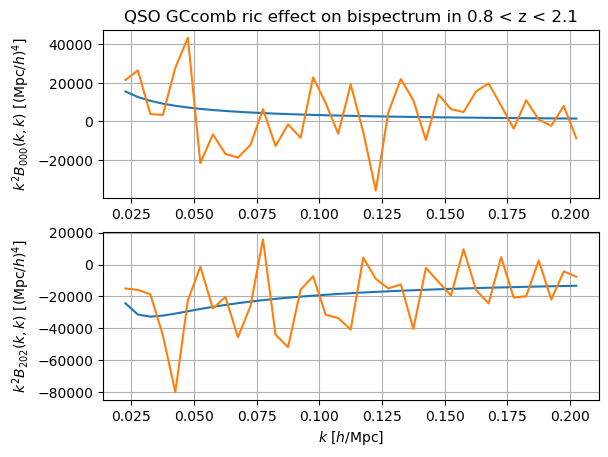

In [5]:
region = 'GCcomb'

for effect in ['amr', 'ric'][1:]:
    for tracer in ['BGS', 'LRG', 'ELG', 'QSO']:
        for zrange in tools.propose_fiducial('zranges', tracer):
            for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
                smooth, effects, noeffects = get_smooth_template(tracer=tracer, zrange=zrange, region=region, effect=effect, kind=kind, return_stats=True)
                mean_effect, mean_noeffect = types.mean(effects), types.mean(noeffects)
                smooth = smooth.select(k=(0.02, 1.))
                mean_effect, mean_noeffect = mean_effect.match(smooth), mean_noeffect.match(smooth)
                fig, lax = plt.subplots(len(smooth.ells))
                lax = lax.ravel()
                if kind == 'mesh2_spectrum':
                    lax[0].set_title(f'{tracer} {region} {effect} effect on spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                    for ill, ell in enumerate(smooth.ells):
                        pole = smooth.get(ell)
                        ax = lax[ill]
                        ax.plot(k:=pole.coords('k'), k * pole.value(), linestyle='-', color='C0')
                        pole_effect, pole_noeffect = mean_effect.get(ell), mean_noeffect.get(ell)
                        ax.plot(k:=pole_effect.coords('k'), k * (pole_effect.value() - pole_noeffect.value()), linestyle='-', color='C1')
                        ax.grid(True)
                        ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                elif kind == 'mesh3_spectrum':
                    lax[0].set_title(f'{tracer} {region} {effect} effect on bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                    for ill, ell in enumerate(smooth.ells):
                        pole = smooth.get(ell)
                        ax = lax[ill]
                        ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), linestyle='-', color='C0')
                        pole_effect, pole_noeffect = mean_effect.get(ell), mean_noeffect.get(ell)
                        ax.plot(k:=pole_effect.coords('k')[..., 0], k**2 * (pole_effect.value() - pole_noeffect.value()), linestyle='-', color='C1')
                        ax.grid(True)
                        ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')